In [0]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [0]:
spark = SparkSession.builder.appName("TextProcessing").getOrCreate()

In [0]:
file_path = "/Volumes/students/default/filestore/sejong_university_wikipedia.txt"
df = spark.read.text(file_path)
df.show(10, truncate=False)
print("Total Lines: ", df.count())


+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                                       |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|SEJONG UNIVERSITY (세종대학교) - WIKIPEDIA ARTI

In [0]:
# Basic text statistics
import re

rows = df.collect()
text = " ".join([r["value"] for r in rows])
num_chars = len(text)
num_lines = len(rows)
words_list = re.findall(r"[A-Za-z']+", text)
lower_words = [w.lower() for w in words_list]
unique_words = set(lower_words)
avg_word_len = sum(len(w) for w in words_list) / max(len(words_list), 1)

print(f"Characters      : {num_chars}")
print(f"Lines           : {num_lines}")
print(f"Total words     : {len(words_list)}")
print(f"Unique words    : {len(unique_words)}")
print(f"Avg word length : {avg_word_len:.2f}")

Characters      : 9543
Lines           : 105
Total words     : 1162
Unique words    : 437
Avg word length : 5.83


In [0]:
#word frequncy
from pyspark.sql.functions import col, explode, split, lower, \
    regexp_replace, length, count as _count, desc

words_df = df.select(lower(regexp_replace(col("value"), r"[^\w\s]", " ")).\
    alias("clean")).select(explode(split(col("clean"), r"\s+")).alias\
    ("word")).filter(length(col("word")) > 0)

word_counts = words_df.groupBy("word").agg(_count("*").alias("count")).\
    orderBy(desc("count"))

word_counts.show(20, truncate=False)

print("Total tokens:", words_df.count(), "| Unique words:", word_counts.\
    count())

+-----------+-----+
|word       |count|
+-----------+-----+
|and        |66   |
|the        |56   |
|of         |43   |
|in         |43   |
|college    |22   |
|sejong     |19   |
|engineering|18   |
|university |17   |
|a          |16   |
|for        |15   |
|education  |13   |
|korea      |12   |
|by         |11   |
|south      |10   |
|s          |10   |
|business   |10   |
|world      |9    |
|was        |8    |
|tourism    |8    |
|to         |8    |
+-----------+-----+
only showing top 20 rows
Total tokens: 1238 | Unique words: 489


In [0]:
# Sentence splitting & stats

sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
num_sentences = len(sentences)
words_per_sentence = [len(re.findall(r"[A-Za-z']+", s)) for s in sentences]
avg_sent_len = sum(words_per_sentence) / max(num_sentences, 1)

print(f"Total sentences          : {num_sentences}")
print(f"Avg words per sentence   : {avg_sent_len:.2f}")
print(f"Shortest sentence (w)    : {min(words_per_sentence)}")
print(f"Longest sentence (w)     : {max(words_per_sentence)}")
print("\nFirst 3 sentences:")
for i, s in enumerate(sentences[:3], 1):
    print(f"  {i}. {s}")

Total sentences          : 67
Avg words per sentence   : 17.34
Shortest sentence (w)    : 2
Longest sentence (w)     : 102

First 3 sentences:
  1. SEJONG UNIVERSITY (세종대학교) - WIKIPEDIA ARTICLE SUMMARY  ================================================================================ OVERVIEW & KEY INFORMATION ================================================================================ Sejong University (SJU; Korean: 세종대학교; Hanja: 世宗大學校) is a private research university located in Seoul, South Korea.
  2. It is highly regarded for its standing in hospitality and tourism management, dancing, animation, rhythmic gymnastics, computer science, and artificial intelligence (AI).
  3. Founded as the Kyung Sung Humanities Institute, it was renamed in 1978 in honor of Sejong the Great, the fourth king of the Joseon Dynasty and the overseer of the creation of the Korean alphabet, Hangul.


In [0]:
# Stopword removal + top-N filtered word frequencies
from collections import Counter

STOPWORDS = set("""a an and are as at be been being but by for from has 
have had he her his i in is it its of on or our she such that the their 
them they this to was were will with you your we us he she it i my me am 
are was were so not no if then than do does did doing have has had having 
can could should would may might must shall just into about over under 
between among during after before above below up down out off again 
further once here there when where why how all any both each few more 
most other some only own same who whom which what new""".split())

filtered = [w for w in lower_words if w not in STOPWORDS and len(w) > 1]
top_filtered = Counter(filtered).most_common(20)

print("Top 20 words (after stopword removal):")
for w, c in top_filtered:
    print(f"{w:20s} {c}")

print(f"\nFiltered tokens: {len(filtered)} (kept) vs {len(lower_words)} (raw)")

Top 20 words (after stopword removal):
college              22
sejong               19
engineering          18
university           17
th                   14
education            13
korea                11
st                   11
south                10
business             10
world                9
tourism              8
graduate             8
management           7
programs             7
established          7
administration       7
ranked               7
korean               6
seoul                6

Filtered tokens: 823 (kept) vs 1162 (raw)


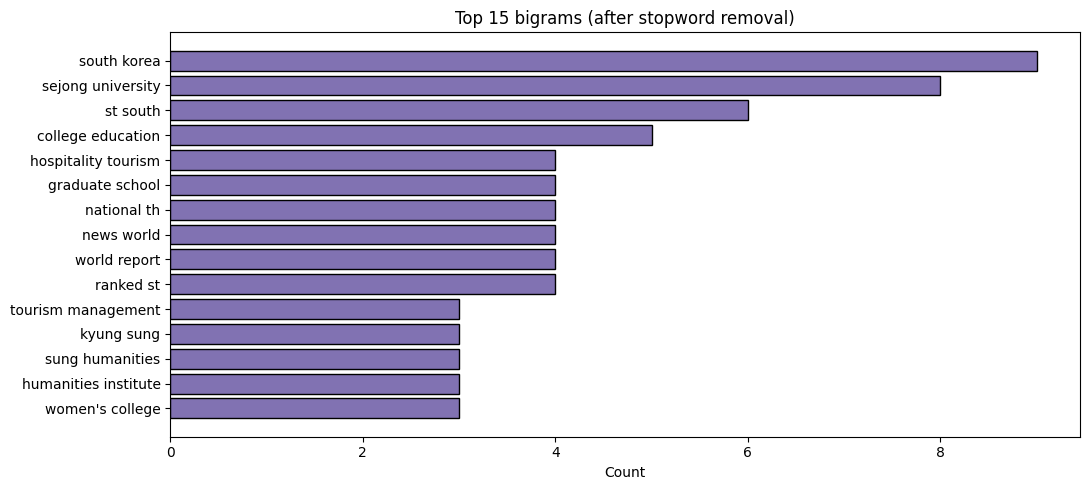

Top bigrams:
south korea: 9
sejong university: 8
st south: 6
college education: 5
hospitality tourism: 4
graduate school: 4
national th: 4
news world: 4
world report: 4
ranked st: 4
tourism management: 3
kyung sung: 3
sung humanities: 3
humanities institute: 3
women's college: 3


In [0]:
import matplotlib.pyplot as plt
# Top bigrams (2-word phrases)

bigrams = list(zip(filtered, filtered[1:]))
bigram_counts = Counter(bigrams).most_common(15)
bg_labels = [f"{a} {b}" for (a, b), _ in bigram_counts]
bg_values = [c for _, c in bigram_counts]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(bg_labels)), bg_values, color="#8172B2", edgecolor="black")

ax.set_yticks(range(len(bg_labels)))
ax.set_yticklabels(bg_labels)
ax.invert_yaxis()

ax.set_title("Top 15 bigrams (after stopword removal)")
ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

print("Top bigrams:")
for (a, b), c in bigram_counts:
    print(f"{a} {b}: {c}")

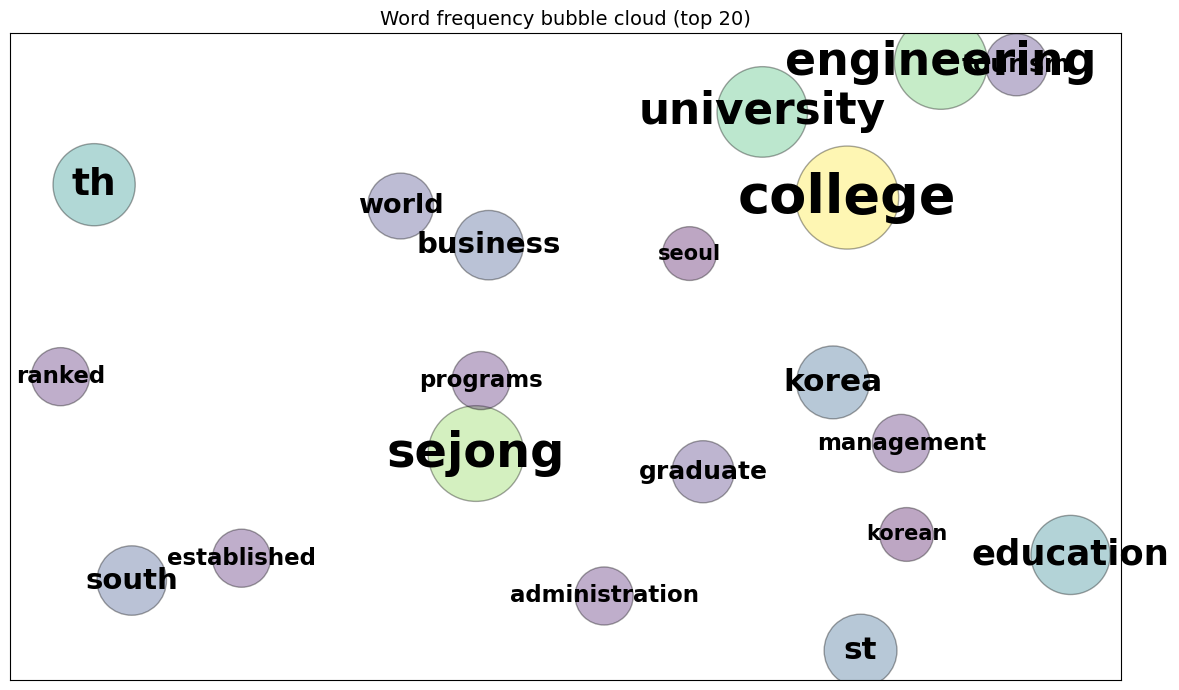

Done. Top 5 covered


In [0]:
import numpy as np

top20 = Counter(filtered).most_common(20)
rng = np.random.default_rng(42)
xs = rng.uniform(0, 10, len(top20))
ys = rng.uniform(0, 10, len(top20))
sizes = np.array([c for _, c in top20])
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(xs, ys, s=sizes * 250, alpha=0.35, c=sizes, cmap="viridis", edgecolor="black")

for (w, c), x, y in zip(top20, xs, ys):
    ax.text(
        x, y, w,
        ha="center", va="center",
        fontsize=6 + c * 1.5,
        fontweight="bold"
    )

ax.set_title("Word frequency bubble cloud (top 20)", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Done. Top 5 covered")

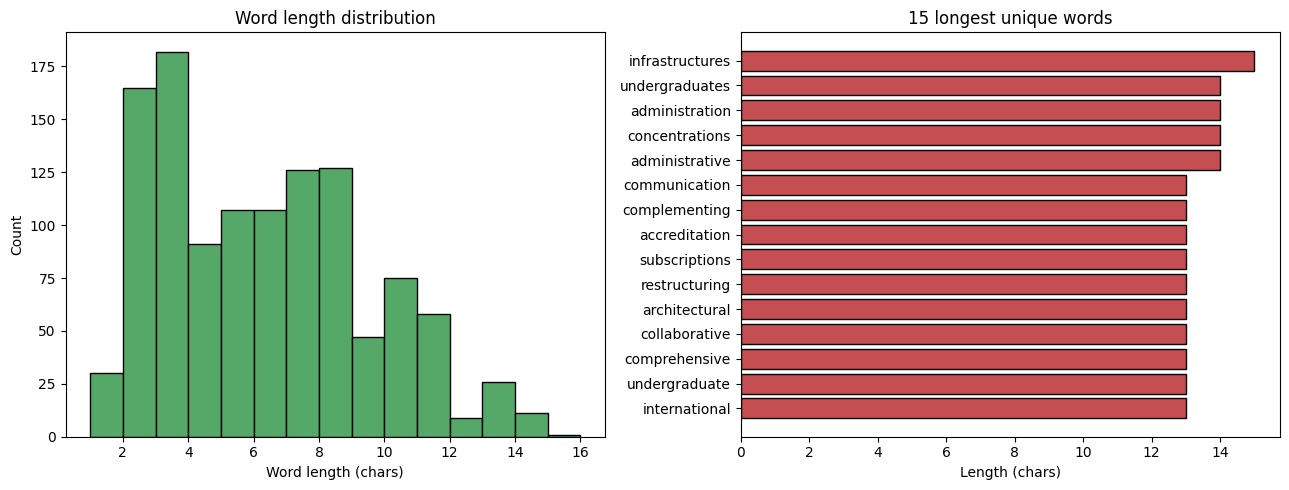

In [0]:
word_lengths = [len(w) for w in lower_words]
longest_words = sorted(set(lower_words), key=len, reverse=True)[:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(word_lengths, bins=range(1, max(word_lengths)+2), color="#55A868", edgecolor="black")
axes[0].set_title("Word length distribution")
axes[0].set_xlabel("Word length (chars)")
axes[0].set_ylabel("Count")

axes[1].barh(range(len(longest_words)), [len(w) for w in longest_words], color="#C44E52", edgecolor="black")
axes[1].set_yticks(range(len(longest_words)))
axes[1].set_yticklabels(longest_words)
axes[1].invert_yaxis()
axes[1].set_title("15 longest unique words")
axes[1].set_xlabel("Length (chars)")

plt.tight_layout()
plt.show()

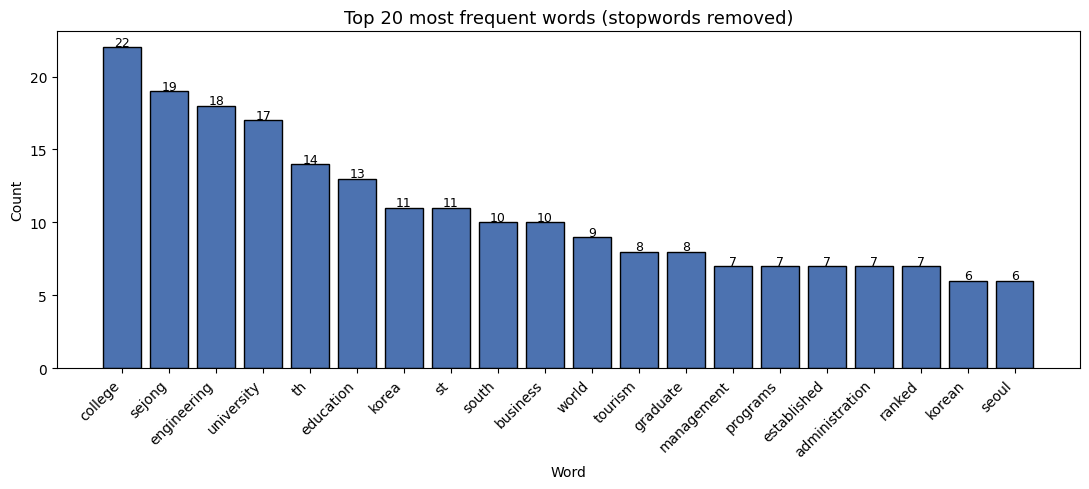

In [0]:
import matplotlib.pyplot as plt

words_top, counts_top = zip(*top_filtered)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(words_top, counts_top, color="#4C72B0", edgecolor="black")
ax.set_title("Top 20 most frequent words (stopwords removed)", fontsize=13)
ax.set_xlabel("Word")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")

for b, c in zip(bars, counts_top):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.1,
        str(c),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [0]:
# 10. Save the results as a CSV inside your Unity Catalog Volume
output_volume_path = "/Volumes/students/default/filestore/sejong_university_wikipedia_results"

word_counts.write.mode("overwrite").option("header", "true").format("csv").save(output_volume_path)